# Análise Exploratória de Dados - Stroke Prediction

**Por Carolina Amorim e Lara Abduni**

Neste trabalho, nós analisamos um conjunto de dados que possui informações de várias pessoas, para tentar entender quais características podem ter uma possível relação com o AVC. 

A coluna analisada é a `stroke`. Quando aparece 0, significa que a pessoa não teve AVC, e quando aparece 1, significa que teve.


In [2]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Configurações
RANDOM_STATE = 42
TEST_SIZE = 0.20
TARGET = "stroke"


## Carregamento e inspeção inicial dos dados


In [3]:
# Baixa o dataset do Kaggle
dataset_path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")

# Carrega o CSV baixado pelo KaggleHub
df = pd.read_csv(f"{dataset_path}/healthcare-dataset-stroke-data.csv")

df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### 1.1 Explicação das features

O dataset possui as seguintes informações:

- `id`: número usado para identificar cada pessoa. Como não diz nada sobre a saúde em si, não vai ser usado no modelo.
- `gender`: mostra o gênero que foi registrado para a pessoa,  uma variável categórica.
- `age`: representa a idade.
- `hypertension`: mostra se a pessoa possui hipertensão: o valor 0 significa não e o 1 significa sim.
- `heart_disease`: mostra se existe alguma doença cardíaca: o valor 0 significa não e o 1 significa sim.
- `ever_married`: informa se a pessoa já foi casada.
- `work_type`: representa o tipo de trabalho da pessoa - como privado, autônomo, público ou criança.
- `Residence_type`: informa se a pessoa mora em uma área urbana ou rural.
- `avg_glucose_level`: mostra o nível médio de glicose da pessoa.
- `bmi`: representa o IMC, que é relacionada ao peso e à altura.
- `smoking_status`: mostra se a pessoa já fumou ou não.
- `stroke`: é a coluna que queremos prever - 0 representa quem não teve AVC e o 1 representa quem teve.


In [4]:
if TARGET not in df.columns:
    raise ValueError(f"A coluna-alvo esperada, {TARGET!r}, não foi encontrada.")

id_cols = [c for c in df.columns if c.lower() in {"id", "patient_id", "patientid"}]
continuous_features = [c for c in ["age", "avg_glucose_level", "bmi"] if c in df.columns]
binary_features = [c for c in ["hypertension", "heart_disease"] if c in df.columns]
nominal_features = [c for c in ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"] if c in df.columns]
predictor_cols = [c for c in df.columns if c not in [TARGET, *id_cols]]

summary = pd.DataFrame({
    "Informação": ["Instâncias", "Colunas totais", "Features preditoras", "Target", "Identificadores removidos"],
    "Resultado": [len(df), df.shape[1], len(predictor_cols), TARGET, ", ".join(id_cols) or "Nenhum"],
})
display(summary)

types_table = pd.DataFrame({
    "dtype no arquivo": df.dtypes.astype(str),
    "tipo conceitual": [
        "identificador" if c in id_cols else
        "target binário" if c == TARGET else
        "numérica contínua" if c in continuous_features else
        "categórica binária" if c in binary_features else
        "categórica nominal"
        for c in df.columns
    ],
    "valores únicos": [df[c].nunique(dropna=True) for c in df.columns],
})
display(types_table)


,Informação,Resultado
0,Instâncias,5110
1,Colunas totais,12
2,Features preditoras,10
3,Target,stroke
4,Identificadores removidos,id


,dtype no arquivo,tipo conceitual,valores únicos
id,int64,identificador,5110
gender,object,categórica nominal,3
age,float64,numérica contínua,104
hypertension,int64,categórica binária,2
heart_disease,int64,categórica binária,2
ever_married,object,categórica nominal,2
work_type,object,categórica nominal,5
Residence_type,object,categórica nominal,2
avg_glucose_level,float64,numérica contínua,3979
bmi,float64,numérica contínua,418


### 1.2 Dimensões e tipos dos dados

Além da inspeção inicial, essa seção aprofunda a caracterização do conjunto. O `df.info()` mostra a contagem de valores não-nulos por coluna, o tipo de cada uma e o uso de memória.

Em seguida, o `describe(include="all")` reúne em uma única tabela as estatísticas das variáveis numéricas (média, desvio padrão, mínimo, quartis e máximo) e das categóricas (número de categorias distintas em `unique`, categoria mais frequente em `top` e sua contagem em `freq`). Isso permite uma visão geral das escalas das numéricas e da composição das categóricas antes das análises univariada e bivariada.

In [23]:
# Visão geral de tipos, contagem de não-nulos e uso de memória
df.info()

# Estatísticas de todas as colunas (numéricas e categóricas juntas).
print("\nEstatísticas descritivas (numéricas e categóricas):")
display(df.drop(columns=id_cols).describe(include="all").T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

Estatísticas descritivas (numéricas e categóricas):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,5110,3,Female,2994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5110.0,NaN,NaN,NaN,43.226614,22.612647,0.08,25.0,45.0,61.0,82.0
hypertension,5110.0,NaN,NaN,NaN,0.097456,0.296607,0.0,0.0,0.0,0.0,1.0
heart_disease,5110.0,NaN,NaN,NaN,0.054012,0.226063,0.0,0.0,0.0,0.0,1.0
ever_married,5110,2,Yes,3353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_type,5110,5,Private,2925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Residence_type,5110,2,Urban,2596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_glucose_level,5110.0,NaN,NaN,NaN,106.147677,45.28356,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,NaN,NaN,NaN,28.893237,7.854067,10.3,23.5,28.1,33.1,97.6
smoking_status,5110,4,never smoked,1892,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.3 Valores ausentes e inconsistências

Depois de entender as colunas, foi verificado se existem valores vazios, linhas repetidas ou informações que parecem estranhas. Essa parte é importante porque esses problemas podem atrapalhar os gráficos e o modelo.

Também é necessário tomar cuidado para não apagar uma informação só porque ela aparece poucas vezes. Por exemplo, `Other` em gênero pode ser uma resposta verdadeira. Já o `Unknown` do tabagismo quer dizer que ninguém sabia aquela informação, então ele não é exatamente a mesma coisa que uma célula vazia.


In [6]:
quality = pd.DataFrame({
    "ausentes": df.isna().sum(),
    "ausentes_%": (df.isna().mean() * 100).round(2),
    "únicos": df.nunique(dropna=True),
})
display(quality.sort_values("ausentes", ascending=False))

print(f"Linhas completamente duplicadas: {df.duplicated().sum()}")
if id_cols:
    print(f"IDs duplicados: {df[id_cols[0]].duplicated().sum()}")
    print(f"Duplicatas desconsiderando o ID: {df.drop(columns=id_cols).duplicated().sum()}")

for col in nominal_features:
    print(f"\nCategorias de {col}:")
    display(df[col].value_counts(dropna=False).to_frame("quantidade"))


,ausentes,ausentes_%,únicos
bmi,201,3.93,418
id,0,0.00,5110
gender,0,0.00,3
age,0,0.00,104
hypertension,0,0.00,2
heart_disease,0,0.00,2
ever_married,0,0.00,2
work_type,0,0.00,5
Residence_type,0,0.00,2
avg_glucose_level,0,0.00,3979


Linhas completamente duplicadas: 0
IDs duplicados: 0
Duplicatas desconsiderando o ID: 0

Categorias de gender:


,quantidade
gender,
Female,2994
Male,2115
Other,1



Categorias de ever_married:


,quantidade
ever_married,
Yes,3353
No,1757


...

,quantidade
work_type,
Private,2925
Self-employed,819
children,687
Govt_job,657
Never_worked,22



Categorias de Residence_type:


,quantidade
Residence_type,
Urban,2596
Rural,2514



Categorias de smoking_status:


,quantidade
smoking_status,
never smoked,1892
Unknown,1544
formerly smoked,885
smokes,789


In [7]:
checks = {}
if "age" in df:
    checks["idade fora de 0 a 120"] = int((~df["age"].between(0, 120) & df["age"].notna()).sum())
if "bmi" in df:
    checks["IMC menor ou igual a zero"] = int((df["bmi"] <= 0).sum())
if "avg_glucose_level" in df:
    checks["glicose menor ou igual a zero"] = int((df["avg_glucose_level"] <= 0).sum())
for col in [*binary_features, TARGET]:
    checks[f"{col} fora de 0 e 1"] = int((~df[col].isin([0, 1]) & df[col].notna()).sum())

display(pd.Series(checks, name="quantidade suspeita").to_frame())


,quantidade suspeita
idade fora de 0 a 120,0
IMC menor ou igual a zero,0
glicose menor ou igual a zero,0
hypertension fora de 0 e 1,0
heart_disease fora de 0 e 1,0
stroke fora de 0 e 1,0


### 1.4 Desbalanceamento da variável target

Nesta parte, foi analisada a quantidade de 0 e 1 na coluna `stroke`. Isso ajuda a perceber se as duas classes possuem tamanhos parecidos. Se quase todo mundo estiver na classe 0, um modelo poderia falar que ninguém teve AVC e ainda parecer que acertou bastante. Por isso, não seria certo olhar apenas para a acurácia depois.


,quantidade,percentual
stroke,,
0,4861,95.13
1,249,4.87


A classe minoritária representa 4.87% dos registros: a variável-alvo está fortemente desbalanceada.


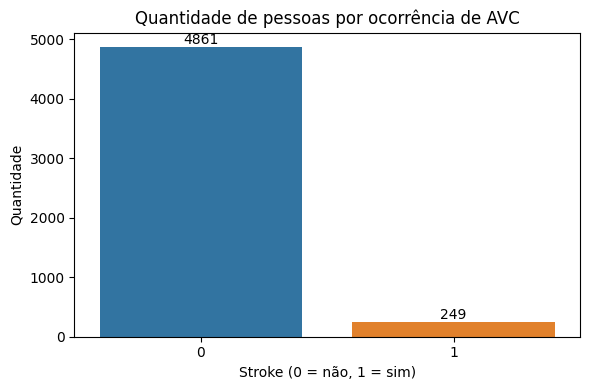

In [8]:
class_table = df[TARGET].value_counts().sort_index().rename("quantidade").to_frame()
class_table["percentual"] = (class_table["quantidade"] / len(df) * 100).round(2)
display(class_table)

minority_share = df[TARGET].value_counts(normalize=True).min()
imbalance_text = "fortemente desbalanceada" if minority_share < 0.10 else "desbalanceada"
print(f"A classe minoritária representa {minority_share:.2%} dos registros: a variável-alvo está {imbalance_text}.")

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x=TARGET, hue=TARGET, legend=False)
ax.set(title="Quantidade de pessoas por ocorrência de AVC", xlabel="Stroke (0 = não, 1 = sim)", ylabel="Quantidade")
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()


### 1.5 Separação dos dados em treino e teste

Os dados foram separados em uma parte de treino e outra de teste. A parte de treino é a que será usada para o modelo aprender, enquanto a de teste vai servir para ver como ele se comporta com dados que não usou antes.

Foi usado o `stratify` para tentar deixar uma proporção parecida de pessoas com AVC nos dois lados. Essa separação foi feita antes de preencher valores ausentes ou mudar as escalas, para não passar informações do teste para o treino sem querer.


In [9]:
model_df = df.dropna(subset=[TARGET]).copy()
X = model_df.drop(columns=[TARGET, *id_cols])
y = model_df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

split_table = pd.DataFrame({
    "conjunto": ["Treino", "Teste"],
    "linhas": [len(X_train), len(X_test)],
    "casos de AVC": [int(y_train.sum()), int(y_test.sum())],
    "AVC_%": [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)],
})
display(split_table)


,conjunto,linhas,casos de AVC,AVC_%
0,Treino,4088,199,4.87
1,Teste,1022,50,4.89


## Análise univariada


### 2.1 Variáveis numéricas

Agora, as variáveis serão observadas uma de cada vez. Para as numéricas, foram calculadas medidas como média, mediana e desvio padrão. Também foram escolhidas idade, glicose e IMC para os gráficos, pois são as três medidas numéricas principais do conjunto.

Nas categóricas, foram escolhidas gênero, tipo de trabalho e situação de tabagismo. A intenção é entender quais respostas aparecem mais e se existe alguma categoria com pouquíssimas pessoas.


In [10]:
numeric_stats = df[continuous_features].agg(["count", "mean", "median", "std", "min", "max"]).T
numeric_stats.columns = ["n", "média", "mediana", "desvio padrão", "mínimo", "máximo"]
display(numeric_stats.round(2))


,n,média,mediana,desvio padrão,mínimo,máximo
age,5110.0,43.23,45.00,22.61,0.08,82.00
avg_glucose_level,5110.0,106.15,91.88,45.28,55.12,271.74
bmi,4909.0,28.89,28.10,7.85,10.30,97.60


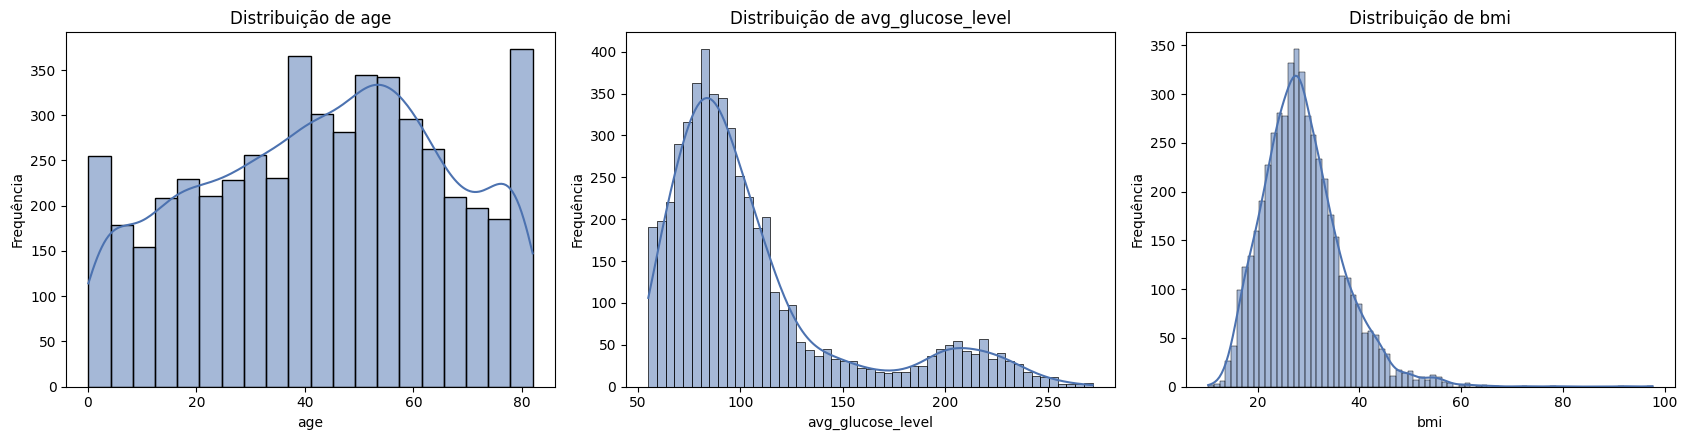

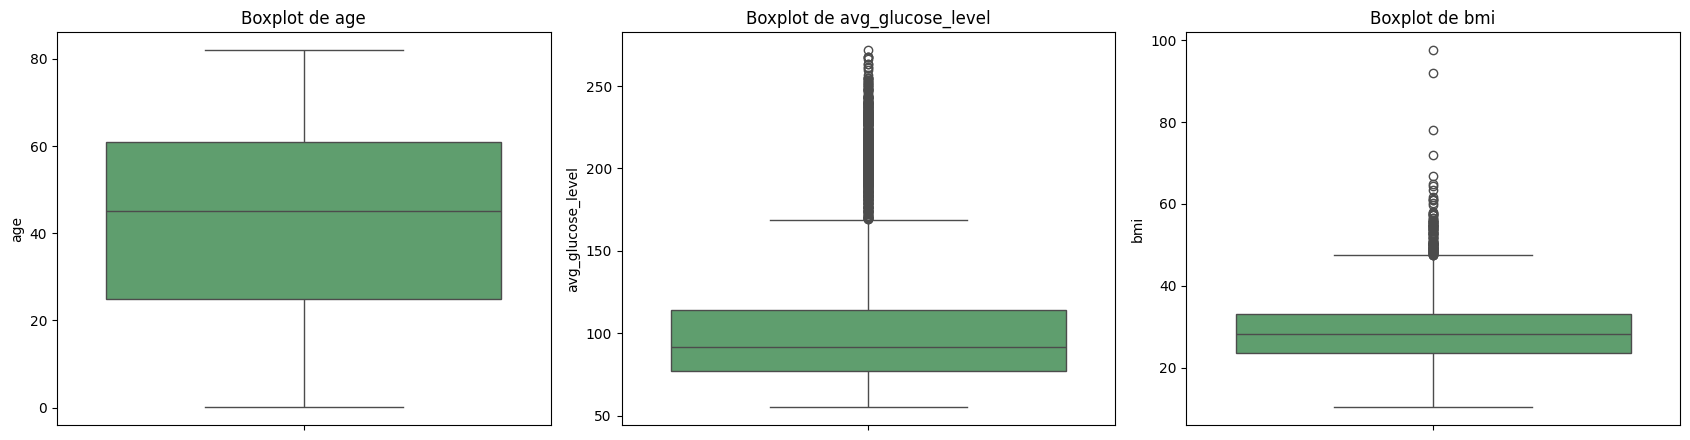

In [11]:
# Visualização numérica 1: histogramas das três variáveis contínuas
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, col in zip(axes, continuous_features):
    sns.histplot(data=df, x=col, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribuição de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()

# Visualização numérica 2: boxplots para identificar assimetria e valores extremos
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, col in zip(axes, continuous_features):
    sns.boxplot(data=df, y=col, ax=ax, color="#55A868")
    ax.set_title(f"Boxplot de {col}")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


### 2.2 Variáveis categóricas



Frequências de gender:


,quantidade,percentual
gender,,
Female,2994,58.59
Male,2115,41.39
Other,1,0.02



Frequências de work_type:


,quantidade,percentual
work_type,,
Private,2925,57.24
Self-employed,819,16.03
children,687,13.44
Govt_job,657,12.86
Never_worked,22,0.43



Frequências de smoking_status:


,quantidade,percentual
smoking_status,,
never smoked,1892,37.03
Unknown,1544,30.22
formerly smoked,885,17.32
smokes,789,15.44


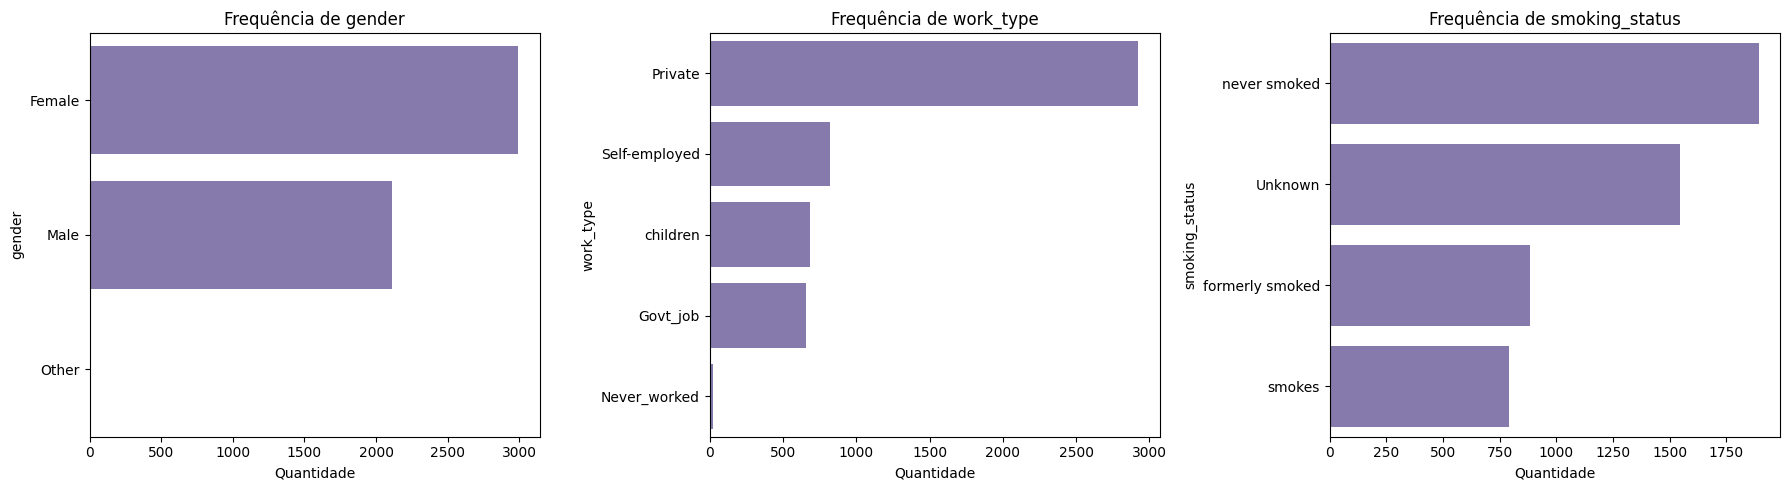

In [12]:
# Frequências categóricas e visualização com, no máximo, três variáveis
selected_categorical = [c for c in ["gender", "work_type", "smoking_status"] if c in df.columns]
for col in selected_categorical:
    freq = df[col].value_counts(dropna=False).rename("quantidade").to_frame()
    freq["percentual"] = (freq["quantidade"] / len(df) * 100).round(2)
    print(f"\nFrequências de {col}:")
    display(freq)

fig, axes = plt.subplots(1, len(selected_categorical), figsize=(18, 5))
axes = np.atleast_1d(axes)
for ax, col in zip(axes, selected_categorical):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax, color="#8172B3")
    ax.set_title(f"Frequência de {col}")
    ax.set_xlabel("Quantidade")
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()


## Análise bivariada e multivariada


### 3.1 Relação entre variáveis numéricas

Foi criada uma matriz de correlação para observar quais variáveis parecem variar de uma forma parecida. Foi usada a correlação de Spearman porque os dados não possuem uma distribuição perfeita e existem valores mais extremos.

Além da matriz, foram feitos dois gráficos de pontos. Um compara idade e glicose e o outro compara idade e IMC. As cores mostram se a pessoa teve AVC ou não.


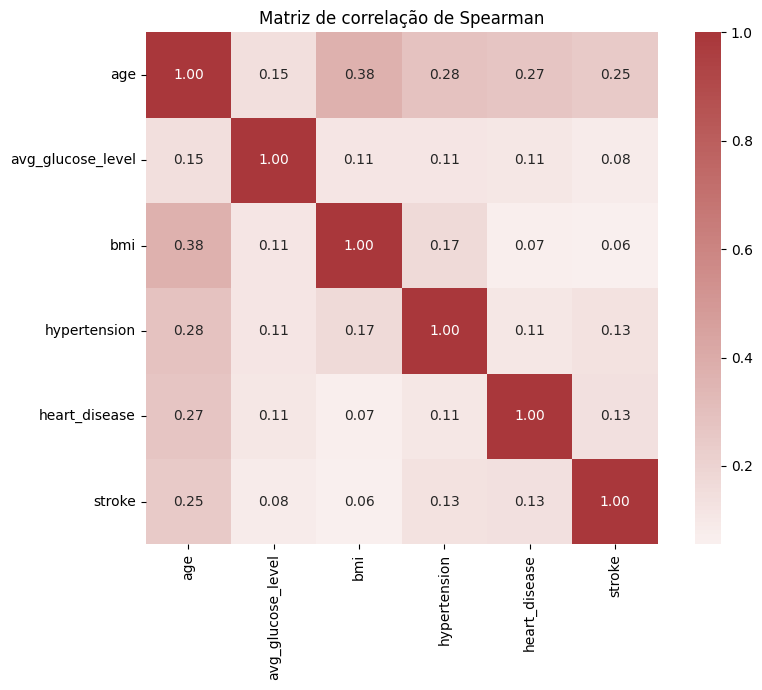

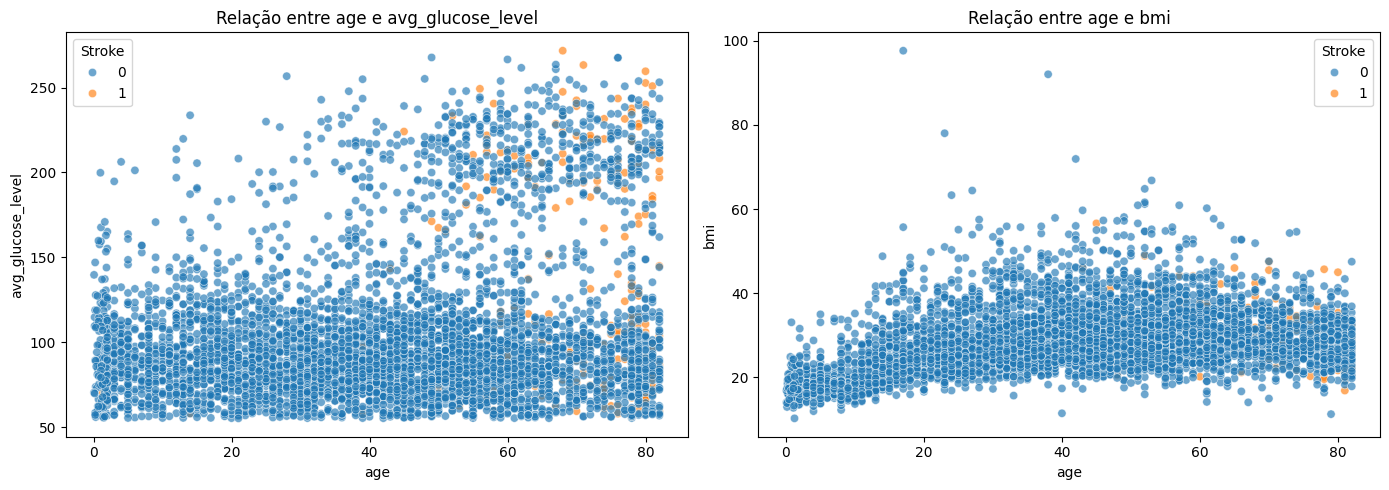

,correlação com stroke
age,0.249531
heart_disease,0.134914
hypertension,0.127904
avg_glucose_level,0.082541
bmi,0.055445


In [13]:
numeric_for_corr = [*continuous_features, *binary_features, TARGET]
corr = df[numeric_for_corr].corr(method="spearman")

# Visualização 1
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Matriz de correlação de Spearman")
plt.tight_layout()
plt.show()

# Visualizações 2 e 3
scatter_pairs = [("age", "avg_glucose_level"), ("age", "bmi")]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (x_col, y_col) in zip(axes, scatter_pairs):
    sns.scatterplot(data=df, x=x_col, y=y_col, hue=TARGET, alpha=0.65, ax=ax)
    ax.set_title(f"Relação entre {x_col} e {y_col}")
    ax.legend(title="Stroke")
plt.tight_layout()
plt.show()

display(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).rename("correlação com stroke").to_frame())


### 3.2 Relação entre variáveis categóricas e stroke

Nesta parte, foram escolhidas as variáveis `work_type`, `smoking_status` e `hypertension`. Para cada uma, foi calculada a quantidade de pessoas e a porcentagem de AVC em cada grupo.

Não é correto olhar apenas para a porcentagem. Se um grupo tiver poucas pessoas, qualquer caso de AVC pode fazer a taxa parecer muito alta. Por isso, a tabela de quantidade também foi colocada junto com o gráfico.



Tabela de contingência: work_type × stroke


stroke,0,1,All
work_type,,,
Govt_job,624,33,657
Never_worked,22,0,22
Private,2776,149,2925
Self-employed,754,65,819
children,685,2,687
All,4861,249,5110


,work_type,quantidade,taxa_AVC_%
3,Self-employed,819,7.94
2,Private,2925,5.09
0,Govt_job,657,5.02
4,children,687,0.29
1,Never_worked,22,0.00



Tabela de contingência: smoking_status × stroke


stroke,0,1,All
smoking_status,,,
Unknown,1497,47,1544
formerly smoked,815,70,885
never smoked,1802,90,1892
smokes,747,42,789
All,4861,249,5110


,smoking_status,quantidade,taxa_AVC_%
1,formerly smoked,885,7.91
3,smokes,789,5.32
2,never smoked,1892,4.76
0,Unknown,1544,3.04



Tabela de contingência: hypertension × stroke


stroke,0,1,All
hypertension,,,
0,4429,183,4612
1,432,66,498
All,4861,249,5110


,hypertension,quantidade,taxa_AVC_%
1,1,498,13.25
0,0,4612,3.97


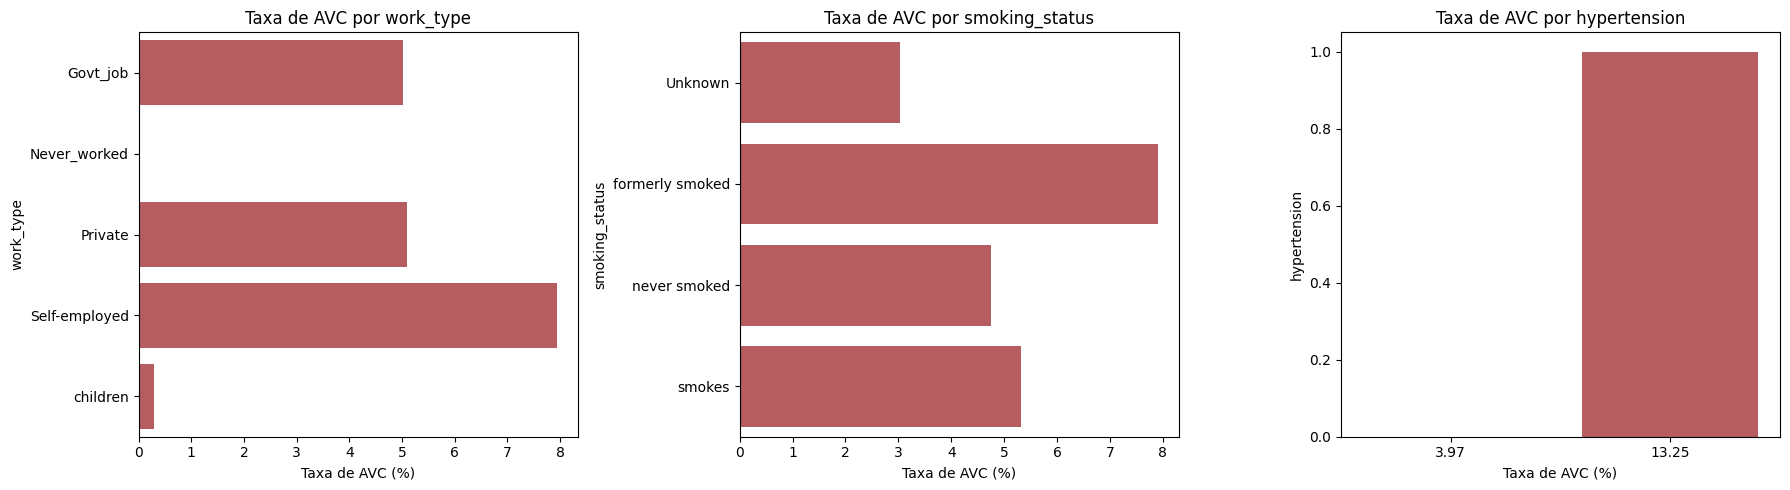

In [14]:
cat_target_features = [c for c in ["work_type", "smoking_status", "hypertension"] if c in df.columns]
rates = {}
for col in cat_target_features:
    print(f"\nTabela de contingência: {col} × {TARGET}")
    display(pd.crosstab(df[col], df[TARGET], margins=True))
    rate = df.groupby(col, dropna=False)[TARGET].agg(quantidade="size", taxa_AVC="mean").reset_index()
    rate["taxa_AVC_%"] = (rate.pop("taxa_AVC") * 100).round(2)
    rates[col] = rate
    display(rate.sort_values("taxa_AVC_%", ascending=False))

fig, axes = plt.subplots(1, len(cat_target_features), figsize=(18, 5))
axes = np.atleast_1d(axes)
for ax, col in zip(axes, cat_target_features):
    sns.barplot(data=rates[col], x="taxa_AVC_%", y=col, ax=ax, color="#C44E52")
    ax.set_title(f"Taxa de AVC por {col}")
    ax.set_xlabel("Taxa de AVC (%)")
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()


### 3.3 Relação entre variáveis numéricas e stroke

Para completar a análise bivariada, cada variável numérica foi distribuída ao longo de uma variável categórica em boxplots. O objetivo é observar como as escalas das numéricas variam entre os grupos categóricos.

O `age × work_type` é o mais considerativo: as categorias `children` e `Never_worked` concentram-se nas idades mais baixas, indicando que esses grupos são praticamente determinados pela idade — uma redundância importante de ter considerar na modelagem. Já `avg_glucose_level × smoking_status` apresenta distribuições semelhantes entre os grupos, o que sugere uma relação fraca entre fumar e o nível de glicose. Por fim, `bmi × ever_married` mostra IMC mais alto entre pessoas já casadas, o que provavelmente reflete a associação indireta com a idade.


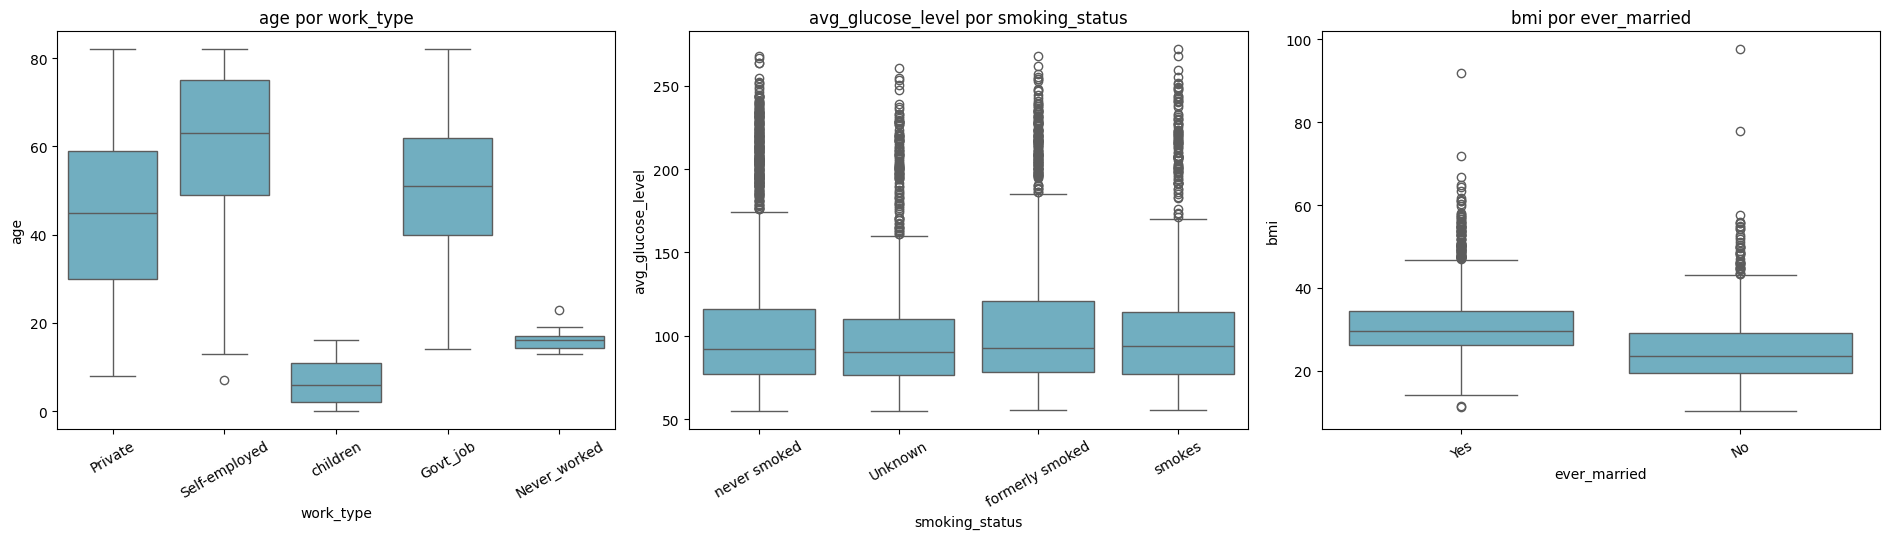

In [25]:
# Boxplots - cada variável númerica distribuída por uma variável categóriga

pares_num_cat = [
    ("age", "work_type"), # idade tende a variar muito entre tipos de trabalho
    ("avg_glucose_level", "smoking_status"),
    ("bmi", "ever_married"),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for ax, (num_col, cat_col) in zip(axes, pares_num_cat):
    order = df[cat_col].value_counts().index
    sns.boxplot(data=df, x=cat_col, y=num_col, order=order, ax=ax, color="#64B5CD")
    ax.set_title(f"{num_col} por {cat_col}")
    ax.set_xlabel(cat_col)
    ax.set_ylabel(num_col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Pré-processamento para modelagem


### 4.1 Tratamento de valores ausentes

Nos valores ausentes das colunas numéricas, foi escolhida a mediana. Essa escolha foi feita porque a mediana não muda tanto por causa de valores muito altos ou baixos. Se faltar algum valor em uma coluna categórica, será usada a resposta que mais aparece. O `Unknown` do tabagismo vai continuar como uma categoria, porque ele já possui um significado.


### 4.2 Tratamento de outliers

Nos outliers, em vez de apagar a linha inteira, o código vai limitar os valores usando o intervalo interquartil. Foi escolhido fazer dessa forma porque já existem poucas pessoas que tiveram AVC e apagar várias linhas poderia piorar isso. Mesmo assim, isso não quer dizer que todo valor alto esteja errado, pois seria necessário ter mais conhecimento da área da saúde para afirmar isso.


In [16]:
class IQRClipper(BaseEstimator, TransformerMixin):
    # Aprende limites pelo IQR no treino e restringe valores extremos sem remover linhas.
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        values = np.asarray(X, dtype=float)
        q1 = np.nanpercentile(values, 25, axis=0)
        q3 = np.nanpercentile(values, 75, axis=0)
        iqr = q3 - q1
        self.lower_ = q1 - self.factor * iqr
        self.upper_ = q3 + self.factor * iqr
        return self

    def transform(self, X):
        values = np.asarray(X, dtype=float)
        return np.clip(values, self.lower_, self.upper_)


### 4.3 Encoding das variáveis categóricas

Nas variáveis categóricas, será usado o One-Hot Encoding. Ele cria colunas de 0 e 1 para cada resposta. O Label Encoding não foi escolhido porque poderia fazer o modelo entender que existe uma ordem entre coisas como profissões, mesmo que essa ordem não exista.


### 4.4 Padronização das variáveis numéricas

Nas variáveis numéricas, será usado o StandardScaler, pois idade, glicose e IMC estão em escalas diferentes. Por fim, o PCA vai tentar resumir essas informações em menos componentes.


### 4.5 PCA

O PCA foi usado para juntar as informações de idade, glicose e IMC em dois componentes. Isso facilita colocar as pessoas em um gráfico de duas dimensões. Se as cores ficarem muito separadas, pode existir uma diferença mais clara entre as classes. Se elas ficarem todas misturadas, significa que só essas três variáveis não conseguem separar tão bem quem teve ou não AVC.

A tabela de pesos ajuda a ver qual variável teve mais influência na criação de cada componente. Porém, isso não quer dizer que ela seja a causa do AVC, apenas que ajudou mais a formar aquele componente.


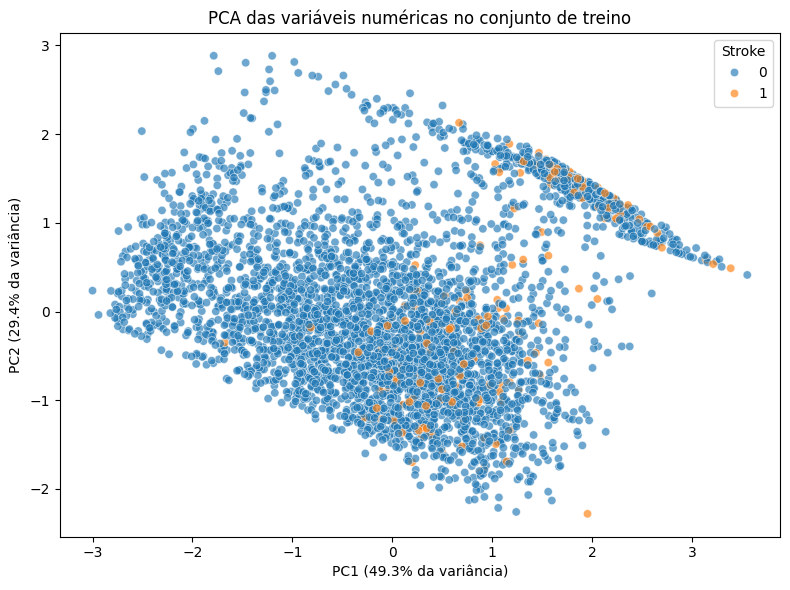

,componente,variância explicada_%,variância acumulada_%
0,PC1,49.29,49.29
1,PC2,29.36,78.65


,PC1,PC2
age,0.643,-0.231
avg_glucose_level,0.453,0.883
bmi,0.617,-0.408


In [17]:
numeric_for_pca = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("outliers", IQRClipper(factor=1.5)),
    ("scaler", StandardScaler()),
])

X_train_num = numeric_for_pca.fit_transform(X_train[continuous_features])
pca_visual = PCA(n_components=2, random_state=RANDOM_STATE)
train_pca = pca_visual.fit_transform(X_train_num)

pca_df = pd.DataFrame(train_pca, columns=["PC1", "PC2"], index=X_train.index)
pca_df[TARGET] = y_train

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=TARGET, alpha=0.65)
plt.title("PCA das variáveis numéricas no conjunto de treino")
plt.xlabel(f"PC1 ({pca_visual.explained_variance_ratio_[0]:.1%} da variância)")
plt.ylabel(f"PC2 ({pca_visual.explained_variance_ratio_[1]:.1%} da variância)")
plt.legend(title="Stroke")
plt.tight_layout()
plt.show()

variance = pd.DataFrame({
    "componente": ["PC1", "PC2"],
    "variância explicada_%": (pca_visual.explained_variance_ratio_ * 100).round(2),
    "variância acumulada_%": (np.cumsum(pca_visual.explained_variance_ratio_) * 100).round(2),
})
loadings = pd.DataFrame(pca_visual.components_.T, index=continuous_features, columns=["PC1", "PC2"])
display(variance)
display(loadings.round(3))


In [18]:
pc_separation = pca_df.groupby(TARGET)[["PC1", "PC2"]].mean().round(3)
display(pc_separation)

distance = np.linalg.norm(pc_separation.loc[1] - pc_separation.loc[0]) if set(pc_separation.index) == {0, 1} else np.nan
top_pc1 = loadings["PC1"].abs().idxmax()
top_pc2 = loadings["PC2"].abs().idxmax()
print(
    f"A distância entre os centros das classes nos dois componentes foi {distance:.2f}. "
    f"A feature com maior peso absoluto no PC1 foi {top_pc1}, enquanto no PC2 foi {top_pc2}. "
    "Mesmo que exista alguma diferença entre os centros, uma grande sobreposição no gráfico indica que as variáveis "
    "numéricas, sozinhas e de forma linear, não separam completamente as classes."
)


,PC1,PC2
stroke,,
0,-0.053,-0.005
1,1.026,0.101


A distância entre os centros das classes nos dois componentes foi 1.08. A feature com maior peso absoluto no PC1 foi age, enquanto no PC2 foi avg_glucose_level. Mesmo que exista alguma diferença entre os centros, uma grande sobreposição no gráfico indica que as variáveis numéricas, sozinhas e de forma linear, não separam completamente as classes.


### 4.6 Estratégia para o desbalanceamento das classes

Apenas 4,87% dos registros correspondem a casos de AVC - esse desbalanceamento não é tratado dentro do `preprocessor`: qualquer técnica de balanceamento deve ser aplicada só ao conjunto de treino (nunca ao teste) para não distorcer a avaliação do modelo com dados que não refletem a distribuição real.

As estratégias consideradas para a fase de modelagem foram:

- **Reponderação de classes** (`class_weight="balanced"`): faz o modelo penalizar mais os erros na classe minoritária, sem alterar os dados. É a opção mais simples e não introduz amostras artificiais.

- **Oversampling da minoria** (por exemplo, SMOTE): gera exemplos sintéticos da classe de AVC no treino. Deve ser aplicado dentro de um pipeline de validação cruzada (com `imblearn`), reajustando a cada partição para evitar vazamento.

- **Undersampling da maioria**: descarta parte dos casos sem AVC. Menos indicado aqui, pois o número absoluto de casos positivos (249) já é pequeno e reduzir a maioria desperdiçaria informação.

A escolha vai ser validada na fase de modelagem comparando o desempenho com métricas sensíveis ao desbalanceamento — recall e F1-score da classe positiva, além da AUC —, e não pela acurácia, que seria enganosa nesse caso.

### 4.7 Pipeline de pré-processamento

Por último, todas as etapas foram colocadas em um pipeline. Ele preenche os valores ausentes, limita os outliers, padroniza os números, aplica o PCA e transforma as categorias em colunas numéricas.

Fazer isso em um pipeline ajuda a não esquecer nenhuma etapa quando outro modelo for testado. Além disso, as transformações são aprendidas usando o treino e depois apenas aplicadas no teste.


In [19]:
categorical_features = [*binary_features, *nominal_features]

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("outliers", IQRClipper(factor=1.5)),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("numericas", numeric_pipeline, continuous_features),
    ("categoricas", categorical_pipeline, categorical_features),
])

X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

print("Formato do treino original:", X_train.shape)
print("Formato do treino processado:", X_train_processed.shape)
print("Formato do teste processado:", X_test_processed.shape)
processed_dense = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
print("Valores ausentes após o processamento:", int(np.isnan(processed_dense).sum()))

print("Pipeline de pré-processamento pronto para a fase de modelagem.")


Formato do treino original: (4088, 10)
Formato do treino processado: (4088, 23)
Formato do teste processado: (1022, 23)
Valores ausentes após o processamento: 0
Pipeline de pré-processamento pronto para a fase de modelagem.


## Principais achados, limitações e conclusão


**Limitações e possíveis vieses**

Uma das principais limitações identificadas é o desbalanceamento da variável alvo. Dos 5.110 registros, apenas 249 (4,87%) correspondem a pessoas que tiveram AVC. Essa diferença pode fazer com que futuros modelos tenham maior facilidade para prever a classe majoritária (stroke = 0) e apresentem desempenho inferior justamente na identificação dos casos de AVC (stroke = 1). Por isso, a acurácia por si só não será suficiente para avaliar os modelos.

Também foram encontrados 201 valores ausentes na variável bmi, correspondentes a 3,93% do dataset, além de uma quantidade relevante de registros classificados como Unknown em smoking_status. Embora Unknown seja uma categoria presente no próprio dataset e não deve ser automaticamente interpretada como um valor ausente, ela representa uma limitação na análise da relação entre histórico de fumo e ocorrência de AVC.

Algumas categorias possuem poucos registros, o que também exige cuidado na interpretação de taxas calculadas para esses grupos. Uma porcentagem aparentemente alta ou baixa de AVC em uma categoria pequena pode não representar um padrão consistente na população. Além disso, variáveis como gender, idade, tipo de trabalho e local de residência indicam que a composição da amostra pode influenciar os padrões encontrados durante a análise.

Por fim, o dataset não fornece informações suficientes sobre o processo de seleção dos participantes, a origem exata da população ou as condições em que todas as informações foram coletadas. Assim, não é possível garantir que a amostra represente adequadamente outras populações, regiões ou contextos clínicos. Portanto, as relações encontradas nessa EDA devem ser interpretadas como associações presentes neste conjunto de dados, e não como relações causais ou evidências suficientes para diagnóstico de AVC.


**Principais achados**

A análise exploratória permitiu identificar padrões e desafios presentes no dataset. Entre os pontos mais relevantes estão o forte desbalanceamento da variável stroke, a presença de valores ausentes em bmi e as diferenças observadas entre os grupos com e sem AVC em algumas das variáveis analisadas.

A seguir, são apresentados os principais resultados obtidos durante a EDA, calculados a partir dos dados:


In [21]:
missing_cols = quality.query("ausentes > 0").index.tolist()

missing_sentence = (
    ", ".join(
        f"{c} ({quality.loc[c, 'ausentes_%']:.2f}%)"
        for c in missing_cols
    )
    if missing_cols
    else "nenhuma coluna"
)

positive_n = int((df[TARGET] == 1).sum())
positive_pct = (df[TARGET] == 1).mean() * 100

pca_variance = (
    pca_visual.explained_variance_ratio_.sum() * 100
)

top_corr = (
    corr[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
    .index[0]
)

report = f'''
O dataset analisado possui {len(df):,} registros e {df.shape[1]} colunas.
Após desconsiderar a coluna de identificação (`id`) e a variável alvo (`stroke`),
foram utilizadas {len(predictor_cols)} features preditoras. Em relação à
qualidade dos dados, foram identificados valores ausentes em {missing_sentence}.
Para as variáveis numéricas, escolhemos a imputação pela mediana, a fim de evitar a
remoção de registros e reduzindo a influência de valores extremos.

A análise da variável alvo mostrou um forte desbalanceamento entre as classes.
Apenas {positive_n} registros correspondem a pessoas que tiveram AVC,
representando {positive_pct:.2f}% do dataset. Esse desbalanceamento deve ser
considerado na etapa de modelagem, pois um modelo pode apresentar alta acurácia
simplesmente por favorecer a classe majoritária. Por isso, métricas como recall,
precisão e F1-score são importantes para avaliar o desempenho na identificação
dos casos de AVC.

Nas análises bivariadas, a variável numérica com maior correlação com `stroke`
foi {top_corr}. As comparações entre os grupos também mostraram diferenças
principalmente em idade e nível médio de glicose entre pessoas que tiveram e não
tiveram AVC. Essas relações representam associações encontradas no dataset, e não
devem ser interpretadas como relações de causa e efeito.

A aplicação do PCA mostrou que os dois primeiros componentes explicam
aproximadamente {pca_variance:.2f}% da variância das variáveis numéricas
analisadas. Apesar de existir alguma diferença entre as classes, foi observada
sobreposição entre os grupos, indicando que idade, glicose e IMC, de forma
linear, não são suficientes para separar claramente pessoas que tiveram ou não AVC.

Com base nos resultados da EDA, foi construído um pipeline de pré-processamento
para tratar valores ausentes e outliers, aplicar One-Hot Encoding às variáveis
categóricas, padronizar as variáveis numéricas e realizar a redução de
dimensionalidade com PCA. O pipeline foi ajustado somente sobre o conjunto de
treino e depois aplicado ao conjunto de teste, evitando vazamento de
informações e deixando os dados preparados de forma consistente para a etapa
de modelagem.
'''

print(report)


O dataset analisado possui 5,110 registros e 12 colunas.
Após desconsiderar a coluna de identificação (`id`) e a variável alvo (`stroke`),
foram utilizadas 10 features preditoras. Em relação à
qualidade dos dados, foram identificados valores ausentes em bmi (3.93%).
Para as variáveis numéricas, escolhemos a imputação pela mediana, a fim de evitar a
remoção de registros e reduzindo a influência de valores extremos.

A análise da variável alvo mostrou um forte desbalanceamento entre as classes.
Apenas 249 registros correspondem a pessoas que tiveram AVC,
representando 4.87% do dataset. Esse desbalanceamento deve ser
considerado na etapa de modelagem, pois um modelo pode apresentar alta acurácia
simplesmente por favorecer a classe majoritária. Por isso, métricas como recall,
precisão e F1-score são importantes para avaliar o desempenho na identificação
dos casos de AVC.

Nas análises bivariadas, a variável numérica com maior correlação com `stroke`
foi age. As comparações entre os grupos

**Conclusão**

A análise exploratória mostrou que o dataset possui 5.110 registros e apresenta um forte desbalanceamento na variável alvo: apenas 249 pessoas (4,87%) tiveram AVC. Além disso, foram encontrados valores ausentes em bmi, correspondentes a 3,93% dos registros. Esses resultados indicam que tanto o desbalanceamento quanto os dados ausentes precisam ser considerados antes da modelagem.

Entre as variáveis numéricas analisadas, age apresentou a maior relação com stroke, com correlação de aproximadamente 0,25. Essa diferença também apareceu na análise por grupos: pessoas que tiveram AVC apresentaram idade média de 67,73 anos, enquanto entre as que não tiveram a média foi de 41,97 anos. A glicose média também foi maior no grupo que teve AVC (132,54 contra 104,80). Entre as variáveis categóricas analisadas, a presença de hipertensão se destacou: 13,25% das pessoas com hipertensão tiveram AVC, contra 3,97% das pessoas sem hipertensão.

O PCA das variáveis numéricas mostrou que os dois primeiros componentes explicam 78,65% da variância dos dados. Apesar de existir alguma diferença entre os centros das duas classes, houve sobreposição entre elas, indicando que idade, glicose e IMC, isoladamente, não são suficientes para separar claramente os casos de AVC.

Com base nesses resultados, foi construído um pipeline de pré-processamento que trata valores ausentes, limita outliers, padroniza as variáveis numéricas, aplica PCA e realiza One-Hot Encoding das variáveis categóricas. Dessa forma, os dados ficam preparados de maneira consistente para a próxima etapa de modelagem. Como a classe de pessoas que tiveram AVC representa apenas 4,87% do dataset, a avaliação dos futuros modelos deverá considerar métricas como recall, precisão e F1-score, e não apenas a acurácia.
